In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid")
PROC_DIR = Path("../data/processed")

d = joblib.load(PROC_DIR / "splits.joblib")
Xtr, Xte = d["Xtr"], d["Xte"]
y_train, y_test = d["y_train_q"], d["y_test_q"]

print("Train:", Xtr.shape, "| Test:", Xte.shape)
print("Classes:", y_train.nunique())

Train: (9520, 20000) | Test: (2381, 20000)
Classes: 10


In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", C=1.0
    ),
    "Linear SVM": LinearSVC(class_weight="balanced", C=0.5),
}

for name, model in models.items():
    model.fit(Xtr, y_train)
    print(f"{name}: trained")

Naive Bayes: trained
Logistic Regression: trained
Linear SVM: trained


In [4]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)
xgb.fit(Xtr, y_train_enc)
print("XGBoost: trained")

XGBoost: trained


In [5]:
from sklearn.metrics import accuracy_score, f1_score

results = []
for name, model in models.items():
    pred = model.predict(Xte)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro-F1": f1_score(y_test, pred, average="macro"),
        "Weighted-F1": f1_score(y_test, pred, average="weighted"),
    })

pred_xgb = le.inverse_transform(xgb.predict(Xte))
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, pred_xgb),
    "Macro-F1": f1_score(y_test, pred_xgb, average="macro"),
    "Weighted-F1": f1_score(y_test, pred_xgb, average="weighted"),
})

res = pd.DataFrame(results).sort_values("Macro-F1", ascending=False)
print(res.round(4).to_string(index=False))
print(f"\nBaseline (majority class): 0.286 accuracy")

              Model  Accuracy  Macro-F1  Weighted-F1
         Linear SVM    0.5191    0.4906       0.5185
            XGBoost    0.5061    0.4301       0.4918
Logistic Regression    0.4406    0.4232       0.4432
        Naive Bayes    0.4704    0.3435       0.4456

Baseline (majority class): 0.286 accuracy


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

best_name = res.iloc[0]["Model"]
best_pred = pred_xgb if best_name == "XGBoost" else models[best_name].predict(Xte)
print(f"=== {best_name} ===\n")
print(classification_report(y_test, best_pred, zero_division=0))

=== Linear SVM ===

                                 precision    recall  f1-score   support

           Billing and Payments       0.73      0.78      0.75       259
               Customer Service       0.45      0.44      0.44       371
                General Inquiry       0.40      0.41      0.41        34
                Human Resources       0.39      0.63      0.48        41
                     IT Support       0.45      0.46      0.45       278
                Product Support       0.51      0.42      0.46       446
          Returns and Exchanges       0.37      0.44      0.40       116
            Sales and Pre-Sales       0.31      0.39      0.35        66
Service Outages and Maintenance       0.51      0.69      0.59        88
              Technical Support       0.58      0.56      0.57       682

                       accuracy                           0.52      2381
                      macro avg       0.47      0.52      0.49      2381
                   weighted a

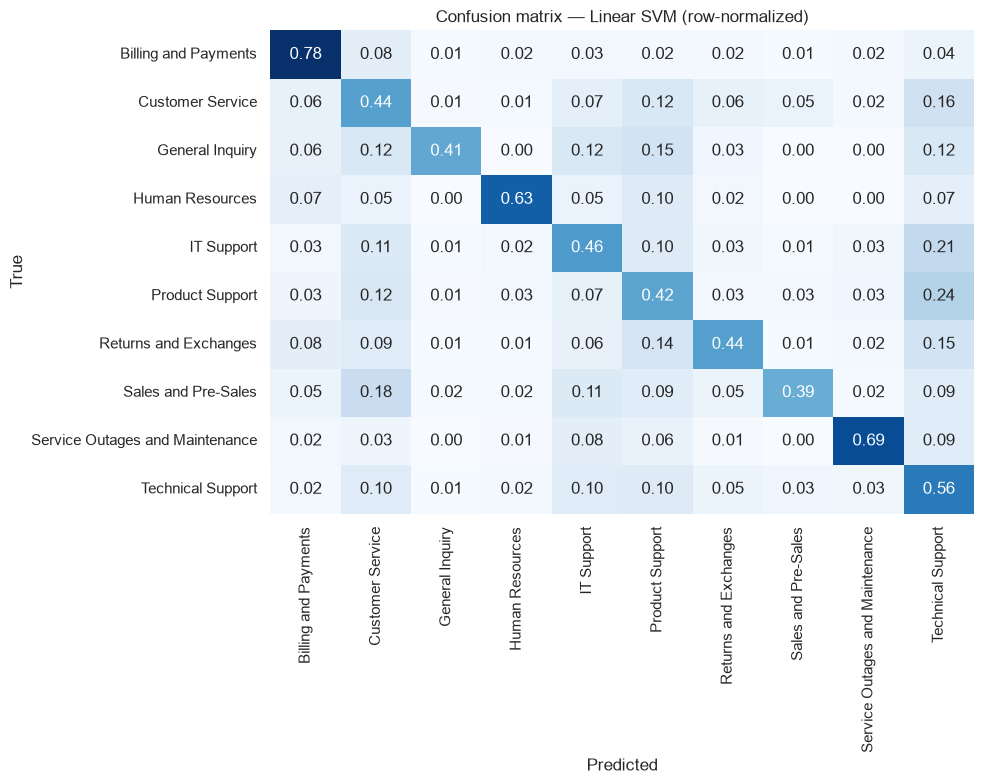

In [7]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion matrix — {best_name} (row-normalized)")
plt.tight_layout()
plt.show()

In [8]:
if best_name in ("Logistic Regression", "Linear SVM"):
    vec = joblib.load("../models/tfidf_vectorizer.joblib")
    feats = np.array(vec.get_feature_names_out())
    model = models[best_name]
    for i, cls in enumerate(model.classes_):
        top = feats[np.argsort(model.coef_[i])[-8:]][::-1]
        print(f"{cls:35s} -> {', '.join(top)}")

Billing and Payments                -> billing, payment, pricing, invoices, invoice, charges, account, subscription
Customer Service                    -> analytics investment, analysis reports, development, services provide, offer data, data linux, ai financial, analysis software
General Inquiry                     -> analysis tools, strategies thank, server integration, breach impacted, branding, effective driving, technology, methods boost
Human Resources                     -> employee, training, hr, moodle, asana redis, inkscape, implement advanced, pytorch
IT Support                          -> marketing tools, importance security, delays project, website, cassandra database, enhance integration, interference, drivers
Product Support                     -> anticipated, task, algorithm, campaign metrics, optimization algorithm, assistance required, rates, inconsistent
Returns and Exchanges               -> return, products, returns, analytics process, powerpoint, product, update p